# Experiment 3: Regression Analysis using Linear and Regularized Models

### Objective
To implement Linear, Ridge, Lasso, and Elastic Net regression models for predicting the loan amount, evaluate their performance using regression metrics, visualize model behavior, and analyze overfitting, underfitting, and the bias–variance trade-off.

# Dataset Used

- **Dataset Name:** Loan Amount Prediction Dataset
- **Number of Records:** 20,000
- **Target Variable:** Loan Amount Request (USD)

## Question 1 : Load the Dataset

In [18]:
import pandas as pd

df=pd.read_csv("test.csv",encoding="latin-1")
print("Successfully loaded")

Successfully loaded


## Question 2: Explore the Dataset

In [19]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.info)
print(df.describe())
print("Null Values:")
print(df.isnull().sum())
print("Duplicates:")
print(df.duplicated().sum())
print(df.columns)

  Customer ID              Name Gender  Age  Income (USD) Income Stability  \
0     C-26247  Tandra Olszewski      F   47       3472.69              Low   
1     C-35067     Jeannette Cha      F   57       1184.84              Low   
2     C-34590      Keva Godfrey      F   52       1266.27              Low   
3     C-16668      Elva Sackett      M   65       1369.72             High   
4     C-12196    Sade Constable      F   60       1939.23             High   

             Profession Type of Employment    Location  \
0  Commercial associate           Managers  Semi-Urban   
1               Working        Sales staff       Rural   
2               Working                NaN  Semi-Urban   
3             Pensioner                NaN       Rural   
4             Pensioner                NaN       Urban   

   Loan Amount Request (USD)  ...  Dependents Credit Score No. of Defaults  \
0                  137088.98  ...         2.0       799.14               0   
1                  104771.

## Question 3 : Data Preprocessing

In [39]:
import pandas as pd
import numpy as np

df.replace("?", np.nan, inplace=True)
df["Property Price"] = df["Property Price"].astype(float)

number_col=df.select_dtypes(include=["number"]).columns

for col in number_col:
    df[col]=df[col].fillna(df[col].median())

string_col=df.select_dtypes(include=["string"]).columns

for col in string_col:
    df[col]=df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())    

print("Total Null:")
print(df.isnull().sum().sum())
      


Customer ID                    0
Name                           0
Gender                         0
Age                            0
Income (USD)                   0
Income Stability               0
Profession                     0
Type of Employment             0
Location                       0
Loan Amount Request (USD)      0
Current Loan Expenses (USD)    0
Expense Type 1                 0
Expense Type 2                 0
Dependents                     0
Credit Score                   0
No. of Defaults                0
Has Active Credit Card         0
Property ID                    0
Property Age                   0
Property Type                  0
Property Location              0
Co-Applicant                   0
Property Price                 0
dtype: int64
Total Null:
0


## Question 4: Exploratory Data Analysis (EDA)

STATISTICAL SUMMARY
                Age  Income (USD)  Loan Amount Request (USD)  \
count  20000.000000  20000.000000               20000.000000   
mean      39.940500   2525.280192               88859.076706   
std       16.097618   1390.372931               60007.333673   
min       18.000000    368.590000                6185.480000   
25%       25.000000   1678.365000               40889.030000   
50%       40.000000   2224.590000               74565.990000   
75%       55.000000   3047.982500              120068.852500   
max       65.000000  30427.680000              576335.680000   

       Current Loan Expenses (USD)    Dependents  Credit Score  \
count                 20000.000000  20000.000000  20000.000000   
mean                    408.319340      2.236900    738.839313   
std                     215.409556      0.927373     71.048813   
min                      41.370000      1.000000    580.040000   
25%                     251.345000      2.000000    682.487500   
50%    

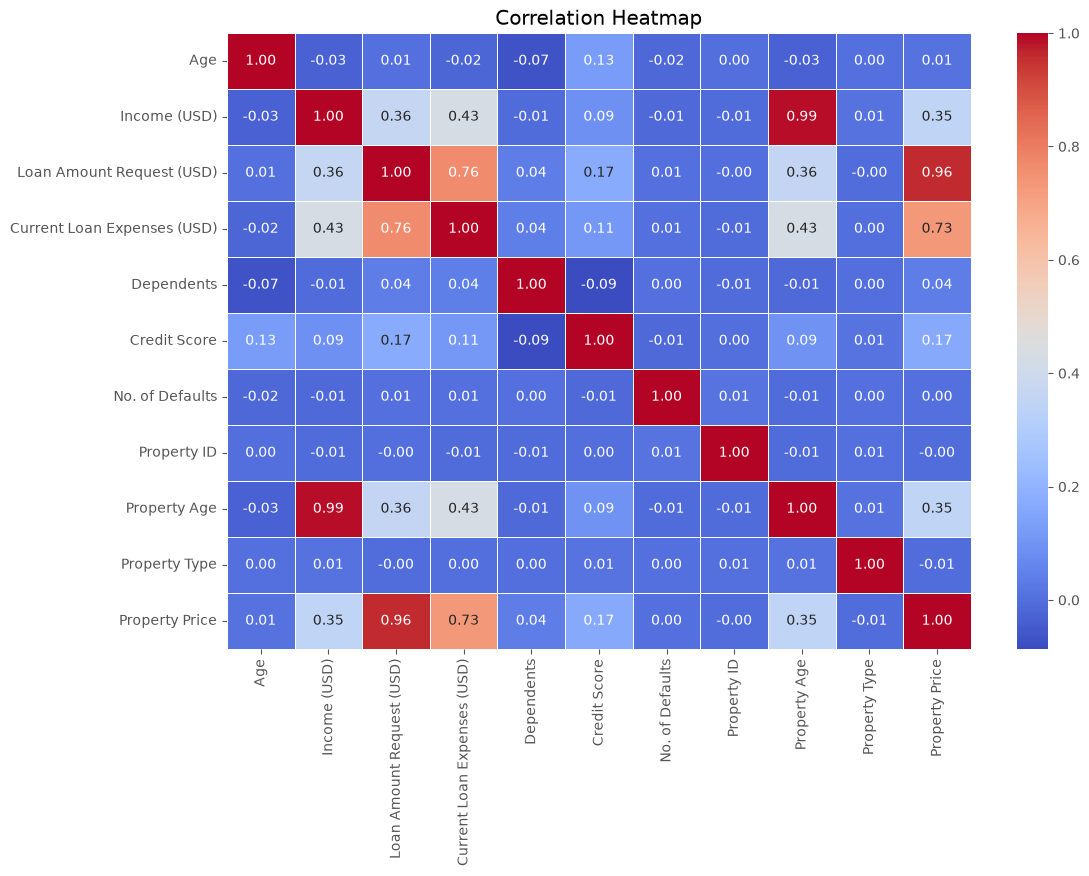

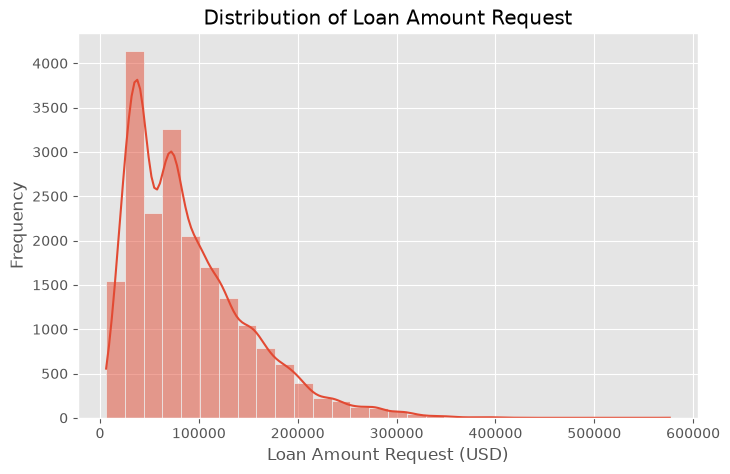

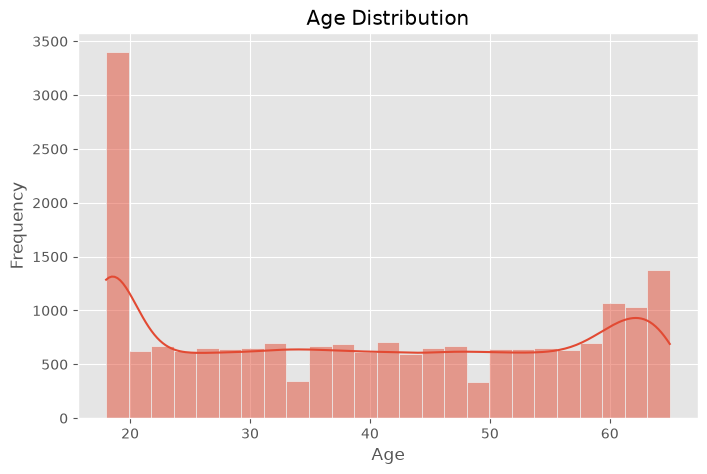

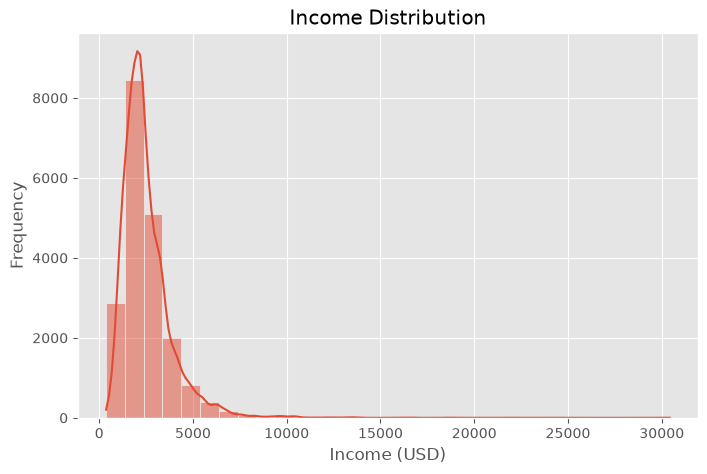

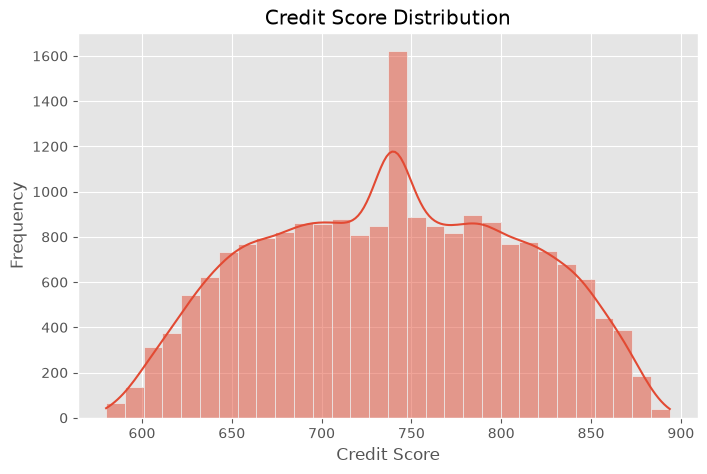

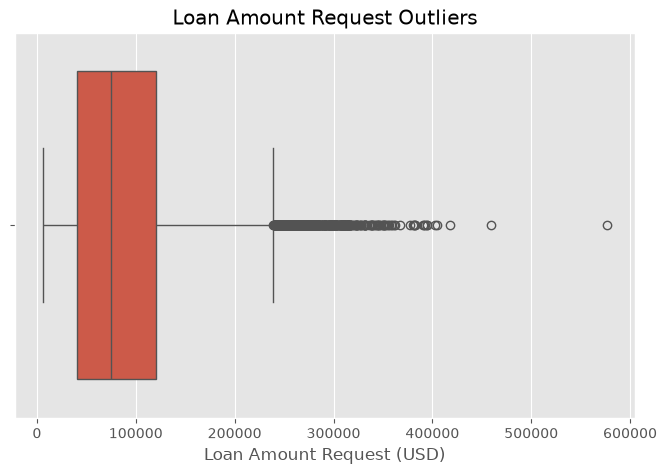

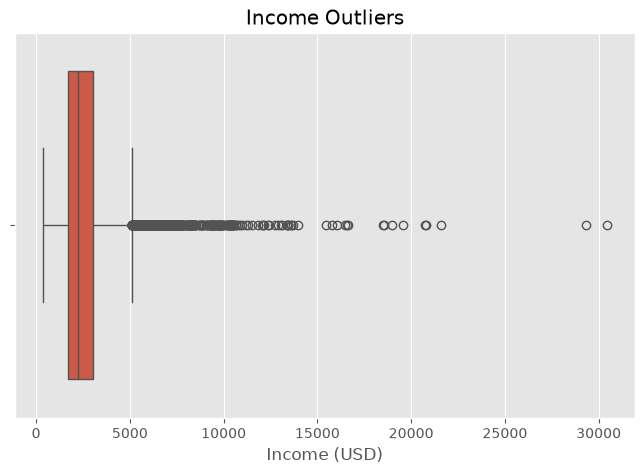

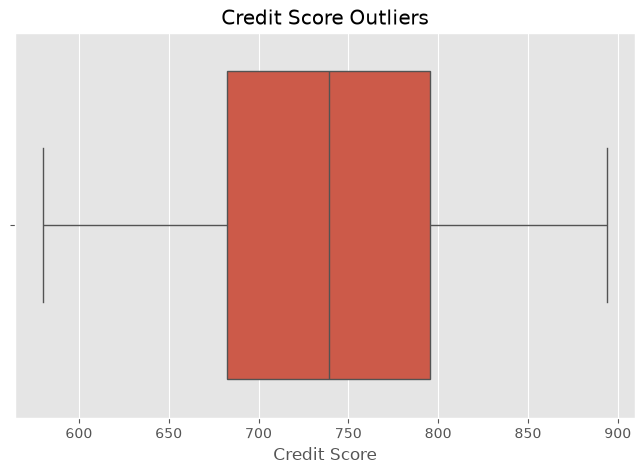

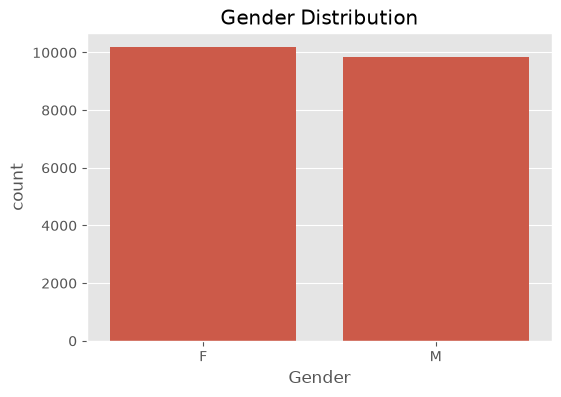

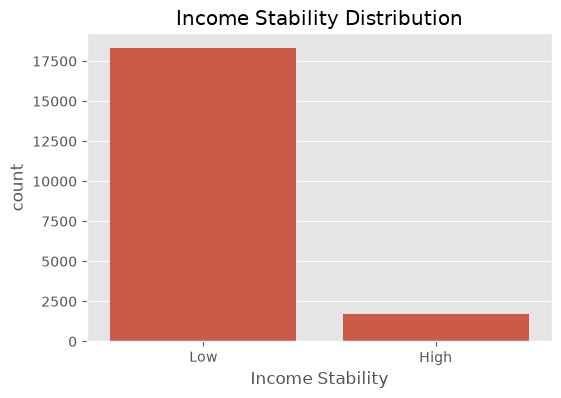

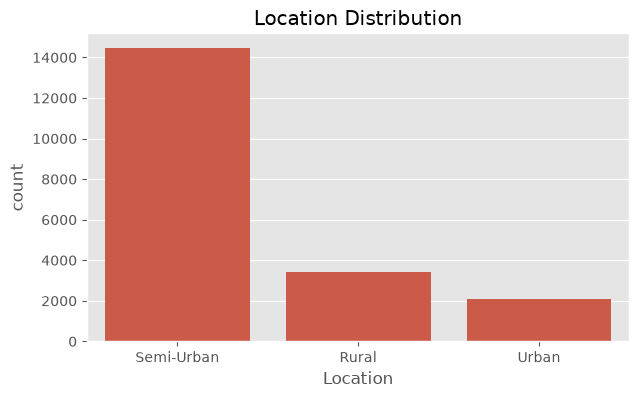

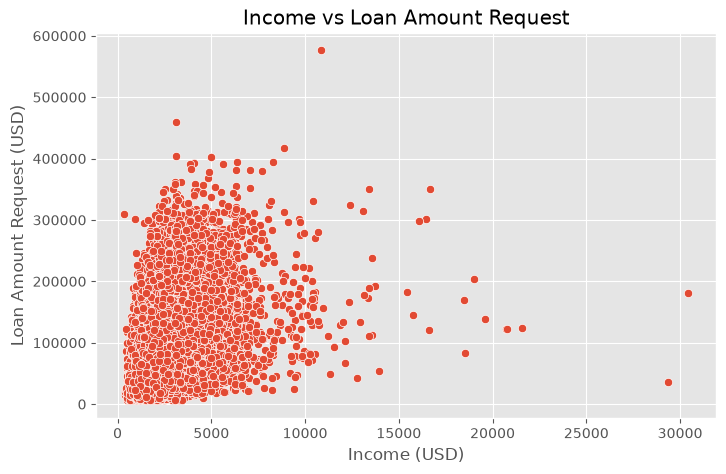

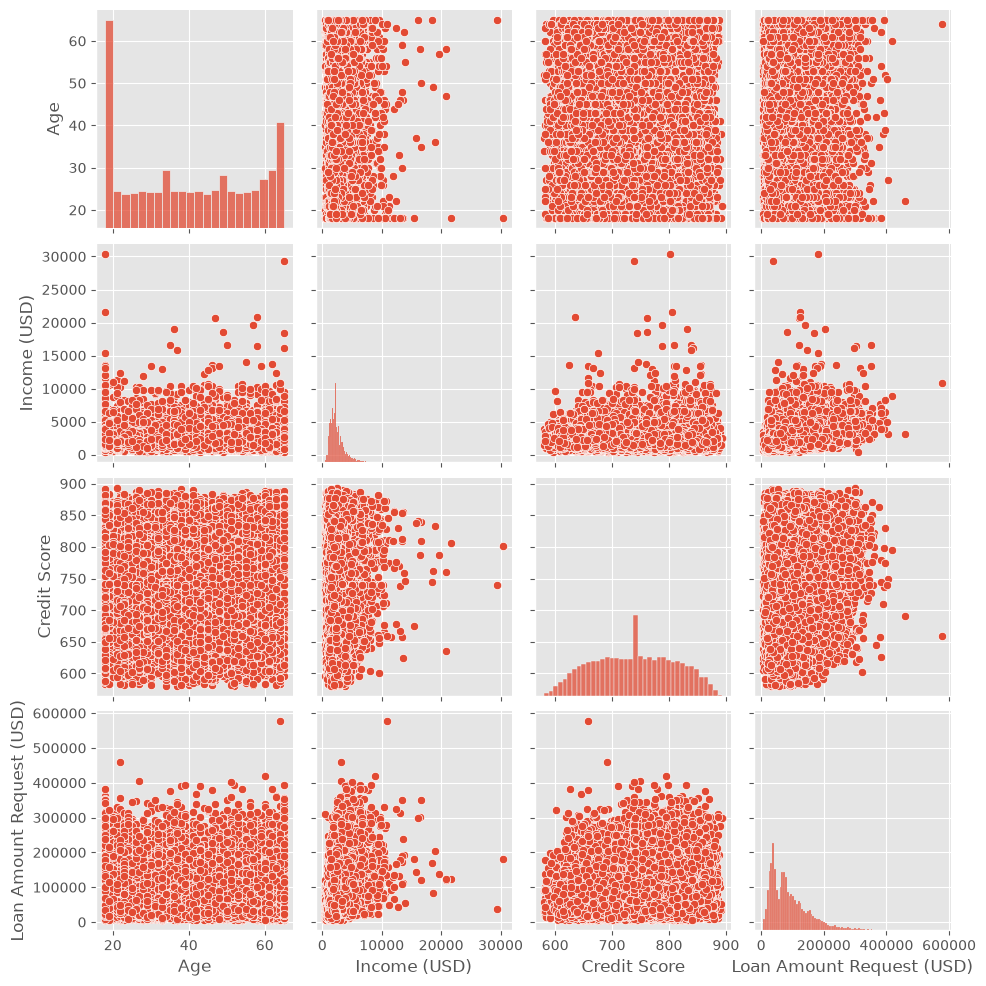



MISSING VALUES
Customer ID                    0
Name                           0
Gender                         0
Age                            0
Income (USD)                   0
Income Stability               0
Profession                     0
Type of Employment             0
Location                       0
Loan Amount Request (USD)      0
Current Loan Expenses (USD)    0
Expense Type 1                 0
Expense Type 2                 0
Dependents                     0
Credit Score                   0
No. of Defaults                0
Has Active Credit Card         0
Property ID                    0
Property Age                   0
Property Type                  0
Property Location              0
Co-Applicant                   0
Property Price                 0
dtype: int64


DUPLICATE RECORDS
0


In [40]:
# ============================================
# Exploratory Data Analysis (EDA)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# --------------------------------------------
# 1. Statistical Summary
# --------------------------------------------

print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)

print(df.describe())

# --------------------------------------------
# 2. Correlation Matrix
# --------------------------------------------

print("\n")
print("="*60)
print("CORRELATION MATRIX")
print("="*60)

correlation = df.corr(numeric_only=True)

print(correlation)

# --------------------------------------------
# 3. Correlation Heatmap
# --------------------------------------------

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# --------------------------------------------
# 4. Distribution of Loan Amount Request
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    df["Loan Amount Request (USD)"],
    bins=30,
    kde=True
)

plt.title("Distribution of Loan Amount Request")
plt.xlabel("Loan Amount Request (USD)")
plt.ylabel("Frequency")

plt.show()

# --------------------------------------------
# 5. Distribution of Age
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=25,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# --------------------------------------------
# 6. Distribution of Income
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    df["Income (USD)"],
    bins=30,
    kde=True
)

plt.title("Income Distribution")
plt.xlabel("Income (USD)")
plt.ylabel("Frequency")

plt.show()

# --------------------------------------------
# 7. Distribution of Credit Score
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    df["Credit Score"],
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

# --------------------------------------------
# 8. Boxplot - Loan Amount
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Loan Amount Request (USD)"]
)

plt.title("Loan Amount Request Outliers")

plt.show()

# --------------------------------------------
# 9. Boxplot - Income
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Income (USD)"]
)

plt.title("Income Outliers")

plt.show()

# --------------------------------------------
# 10. Boxplot - Credit Score
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Credit Score"]
)

plt.title("Credit Score Outliers")

plt.show()

# --------------------------------------------
# 11. Count Plot - Gender
# --------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    data=df
)

plt.title("Gender Distribution")

plt.show()

# --------------------------------------------
# 12. Count Plot - Income Stability
# --------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x="Income Stability",
    data=df
)

plt.title("Income Stability Distribution")

plt.show()

# --------------------------------------------
# 13. Count Plot - Location
# --------------------------------------------

plt.figure(figsize=(7,4))

sns.countplot(
    x="Location",
    data=df
)

plt.title("Location Distribution")

plt.show()

# --------------------------------------------
# 14. Scatter Plot
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Income (USD)",
    y="Loan Amount Request (USD)",
    data=df
)

plt.title("Income vs Loan Amount Request")

plt.show()

# --------------------------------------------
# 15. Pair Plot
# --------------------------------------------

selected_columns = [
    "Age",
    "Income (USD)",
    "Credit Score",
    "Loan Amount Request (USD)"
]

sns.pairplot(df[selected_columns])

plt.show()

# --------------------------------------------
# 16. Missing Values Check
# --------------------------------------------

print("\n")
print("="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())

# --------------------------------------------
# 17. Duplicate Records
# --------------------------------------------

print("\n")
print("="*60)
print("DUPLICATE RECORDS")
print("="*60)

print(df.duplicated().sum())

## Question 5: Feature Selection, Encoding, Train-Test Split and Feature Scaling

In [47]:
x=df.drop("Loan Amount Request (USD)",axis=1)
y=df["Loan Amount Request (USD)"]

print(x.shape)
print(y.shape)

from sklearn.preprocessing import LabelEncoder

model=LabelEncoder()

string_col=x.select_dtypes(include="string").columns
print(string_col)

for col in string_col:
    x[col]=model.fit_transform(x[col])

print("Encoding done")    

from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)







(20000, 22)
(20000,)
Index(['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession',
       'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2',
       'Has Active Credit Card', 'Property Location', 'Co-Applicant'],
      dtype='str')
Encoding done
(16000, 22)
(4000, 22)
(16000,)
(4000,)
(16000, 22)
(4000, 22)


## Question 6: Linear Regression

In [77]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import time

model=LinearRegression()
start=time.time()

model.fit(X_train,Y_train)
Y_pred_lin=model.predict(X_test)

end=time.time()
lin_training_time=end-start

lin_mae=mean_absolute_error(Y_test,Y_pred_lin)
lin_mse=mean_squared_error(Y_test,Y_pred_lin)
lin_rmse=np.sqrt(mse)
lin_r2=r2_score(Y_test,Y_pred_lin)

print("Mean Absolute error:", lin_mae)
print("Mean Squared error:", lin_mse)
print("Root Mean Squared error:",lin_rmse)
print("R2 Score:", lin_r2)
print("Training time:",lin_training_time)


Mean Absolute error: 10891.307658968077
Mean Squared error: 232962214.02344006
Root Mean Squared error: 22727.75869710231
R2 Score: 0.9355894050959987
Training time: 0.017795562744140625


## Question 7: Ridge Regression

In [76]:
from sklearn.linear_model import Ridge

ridge=Ridge(alpha=1.0)

start=time.time()

ridge.fit(X_train,Y_train)
end=time.time()

rid_training_time=end-start

Y_pred_ridge=ridge.predict(X_test)

rid_mae=mean_absolute_error(Y_test,Y_pred_ridge)
rid_mse=mean_squared_error(Y_test,Y_pred_ridge)
rid_rmse=np.sqrt(mse)
rid_r2=r2_score(Y_test,Y_pred_ridge)


print("Ridge")
            
print("Mean Absolute error:", rid_mae)
print("Mean Squared error:", rid_mse)
print("Root Mean Squared error:", rid_rmse)
print("R2 Score:", rid_r2)
print("Training time:",rid_training_time)

            
            
            

Ridge
Mean Absolute error: 10891.340859315726
Mean Squared error: 232963219.2595813
Root Mean Squared error: 22727.75869710231
R2 Score: 0.9355891271631239
Training time: 0.016831636428833008


## Question 8: Lasso Regression

In [78]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=1.0)

start=time.time()

lasso.fit(X_train,Y_train)
end=time.time()

lasso_training_time=end-start

Y_pred_lasso=lasso.predict(X_test)

lasso_mae=mean_absolute_error(Y_test,Y_pred_lasso)
lasso_mse=mean_squared_error(Y_test,Y_pred_lasso)
lasso_rmse=np.sqrt(mse)
lasso_r2=r2_score(Y_test,Y_pred_lasso)


print("Lasso")
            
print("Mean Absolute error:", lasso_mae)
print("Mean Squared error:", lasso_mse)
print("Root Mean Squared error:", lasso_rmse)
print("R2 Score:", lasso_r2)
print("Training time:",lasso_training_time)


Lasso
Mean Absolute error: 10891.178245641328
Mean Squared error: 232957054.97378278
Root Mean Squared error: 22727.75869710231
R2 Score: 0.9355908314966662
Training time: 1.8107240200042725


## Question 9: ElasticNet Regression


In [79]:
from sklearn.linear_model import ElasticNet
elastic=ElasticNet(alpha=1.0,l1_ratio=0.5)

start=time.time()

elastic.fit(X_train,Y_train)
end=time.time()

els_training_time=end-start

Y_pred_elastic=elastic.predict(X_test)

els_mae=mean_absolute_error(Y_test,Y_pred_elastic)
els_mse=mean_squared_error(Y_test,Y_pred_elastic)
els_rmse=np.sqrt(mse)
els_r2=r2_score(Y_test,Y_pred_elastic)


print("ElasticNet")
            
print("Mean Absolute error:", els_mae)
print("Mean Squared error:", els_mse)
print("Root Mean Squared error:", els_rmse)
print("R2 Score:", els_r2)
print("Training time:",els_training_time)

ElasticNet
Mean Absolute error: 17137.946256495452
Mean Squared error: 516551015.39370954
Root Mean Squared error: 22727.75869710231
R2 Score: 0.8571813101139782
Training time: 0.11595463752746582


## Question 10: Ridge Hyperparameter Tuning 

In [100]:
from sklearn.model_selection import GridSearchCV

ridge=Ridge()

param_grid={"alpha":[0.01,0.1,1,10,100,200]}

grid_ridge=GridSearchCV(estimator=ridge,param_grid=param_grid,cv=5,scoring="r2",return_train_score=True)

grid_ridge.fit(X_train,Y_train)
print("Best Alpha :", grid_ridge.best_params_)
print("Best R2 Score :", grid_ridge.best_score_)


Best Alpha : {'alpha': 10}
Best R2 Score : 0.9301923839832937


## Question 11: Lasso Hyperparameter Tuning

In [101]:
from sklearn.model_selection import GridSearchCV

lasso=Lasso(max_iter=20000)

param_grid={"alpha":[0.01,0.1,1,10,100,200]}

grid_lasso=GridSearchCV(estimator=lasso,param_grid=param_grid,cv=5,scoring="r2",return_train_score=True)

grid_lasso.fit(X_train,Y_train)
print("Best Alpha :", grid_lasso.best_params_)
print("Best R2 Score :", grid_lasso.best_score_)

Best Alpha : {'alpha': 100}
Best R2 Score : 0.9302430109639698


## Question 12:ElasticNet Hyperparamter Tuning

In [102]:
from sklearn.model_selection import GridSearchCV

elastic=ElasticNet()

param_grid={"alpha":[0.01,0.1,1,10,100,200],"l1_ratio": [0.2, 0.5, 0.8]}

grid_elastic=GridSearchCV(estimator=elastic,param_grid=param_grid,cv=5,scoring="r2",return_train_score=True)

grid_elastic.fit(X_train,Y_train)
print("Best Alpha :", grid_elastic.best_params_)
print("Best R2 Score :", grid_elastic.best_score_)

Best Alpha : {'alpha': 0.01, 'l1_ratio': 0.8}
Best R2 Score : 0.9301904988388593


## Question 13: Performance Comaparison Table

In [92]:
comparison=pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Regression"
    ],

    "Mae":[
        lin_mae,
        rid_mae,
        lasso_mae,
        els_mae
    ],

    "Mse":[
        lin_mse,
        rid_mse,
        lasso_mse,
        els_mse
    ],

    "RMSE":[
        lin_rmse,
        rid_rmse,
        lasso_rmse,
        els_rmse
    ],

    "R2 Score":[
        lin_r2,
        rid_r2,
        lasso_r2,
        els_r2
    ],

    "Training time":[
        lin_training_time,
        rid_training_time,
        lasso_training_time,
        els_training_time
    ]
})
print(comparison)

                Model           Mae           Mse          RMSE  R2 Score  \
0   Linear Regression  10891.307659  2.329622e+08  22727.758697  0.935589   
1    Ridge Regression  10891.340859  2.329632e+08  22727.758697  0.935589   
2    Lasso Regression  10891.178246  2.329571e+08  22727.758697  0.935591   
3  Elastic Regression  17137.946256  5.165510e+08  22727.758697  0.857181   

   Training time  
0       0.017796  
1       0.016832  
2       1.810724  
3       0.115955  


## Question 14:Actual Vs Predicted

Ridge


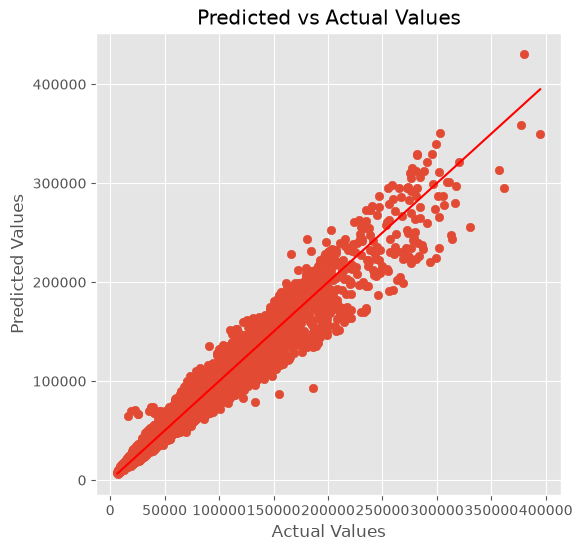

Linear Regression


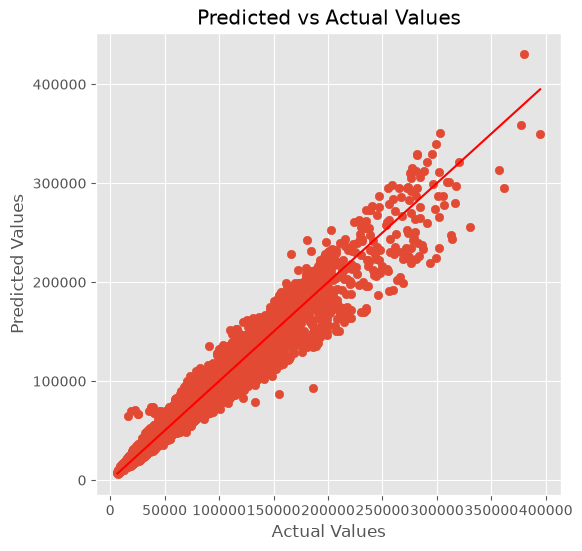

Lasso


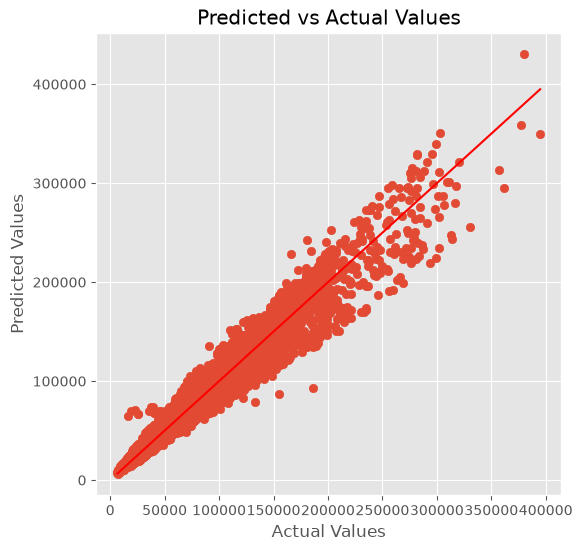

ElasticNet


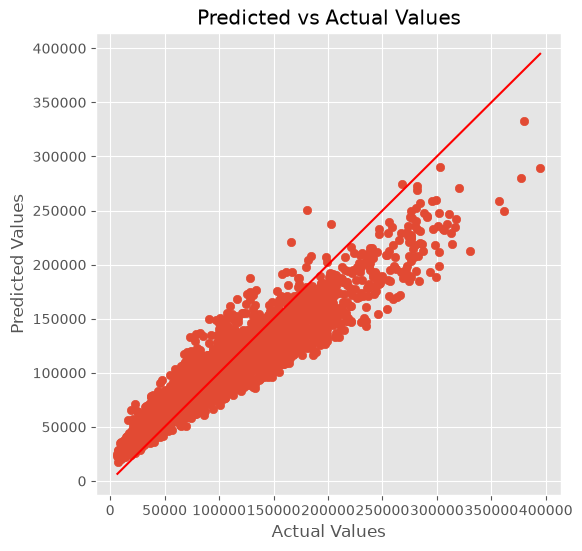

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

print("Ridge")
plt.scatter(Y_test, Y_pred_ridge)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color="red"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")

plt.show()


print("Linear Regression")
plt.figure(figsize=(6,6))


plt.scatter(Y_test, Y_pred_lin)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color="red"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")

plt.show()

print("Lasso")

plt.figure(figsize=(6,6))


plt.scatter(Y_test, Y_pred_lasso)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color="red"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")

plt.show()

print("ElasticNet")
plt.figure(figsize=(6,6))


plt.scatter(Y_test, Y_pred_elastic)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color="red"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")

plt.show()

## Question 15: Residual 

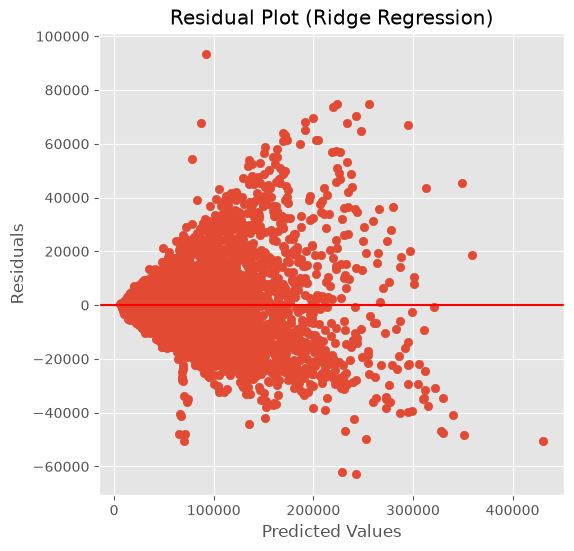

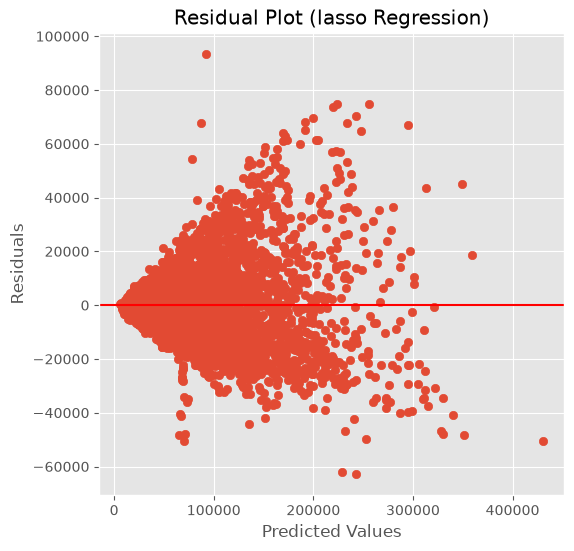

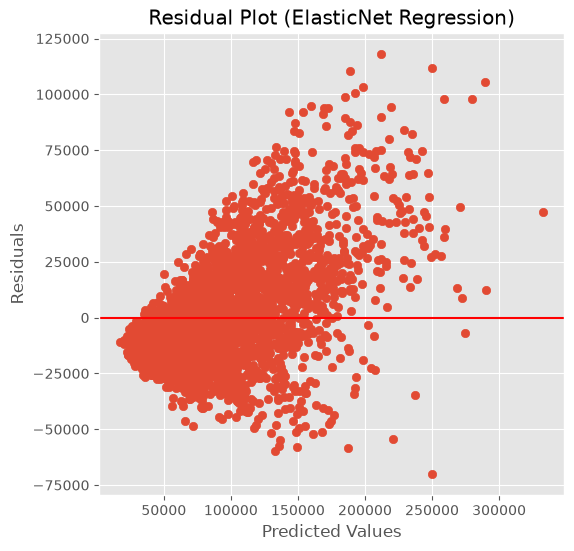

In [99]:
import matplotlib.pyplot as plt

residual = Y_test - Y_pred_ridge

plt.figure(figsize=(6,6))

plt.title("Residual Plot (Ridge Regression)")
plt.scatter(Y_pred_ridge, residual)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")


plt.show()


residual = Y_test - Y_pred_lasso

plt.figure(figsize=(6,6))

plt.title("Residual Plot (lasso Regression)")
plt.scatter(Y_pred_lasso, residual)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")


plt.show()

residual = Y_test - Y_pred_elastic

plt.figure(figsize=(6,6))

plt.title("Residual Plot (ElasticNet Regression)")
plt.scatter(Y_pred_elastic, residual)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")


plt.show()

## Question 16 : Training vs Validation

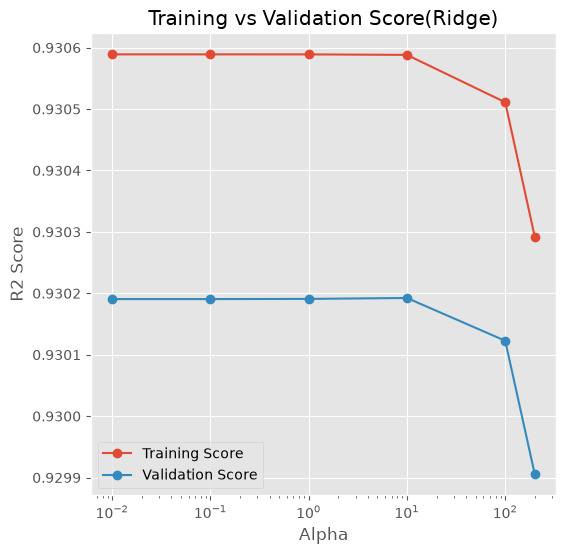

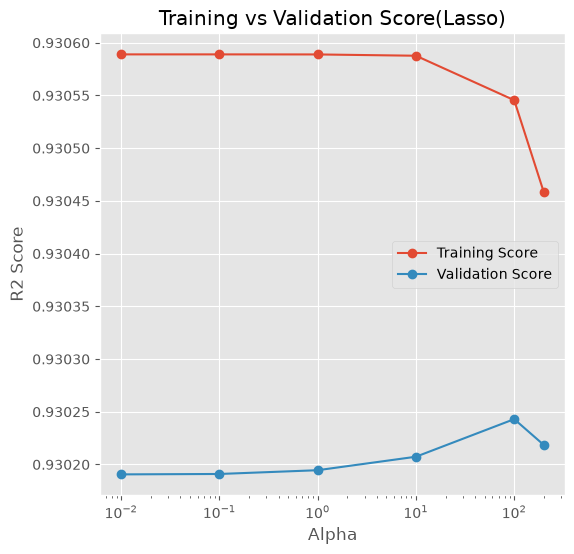

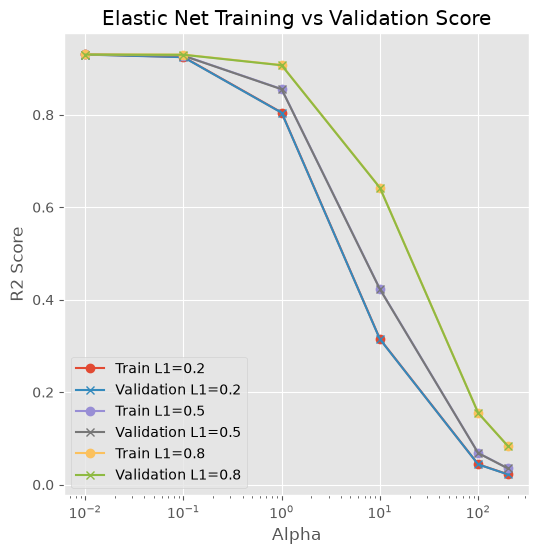

In [112]:
cv = pd.DataFrame(grid_ridge.cv_results_)

plt.figure(figsize=(6,6))
plt.plot(cv["param_alpha"], cv["mean_train_score"], marker="o", label="Training Score")
plt.plot(cv["param_alpha"], cv["mean_test_score"], marker="o", label="Validation Score")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.title("Training vs Validation Score(Ridge)")
plt.legend()

plt.show()


cv = pd.DataFrame(grid_lasso.cv_results_)

plt.figure(figsize=(6,6))
plt.plot(cv["param_alpha"], cv["mean_train_score"], marker="o", label="Training Score")
plt.plot(cv["param_alpha"], cv["mean_test_score"], marker="o", label="Validation Score")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.title("Training vs Validation Score(Lasso)")
plt.legend()

plt.show()

cv = pd.DataFrame(grid_elastic.cv_results_)

plt.figure(figsize=(6,6))

for ratio in cv["param_l1_ratio"].unique():

    temp = cv[cv["param_l1_ratio"] == ratio]

    plt.plot(temp["param_alpha"], temp["mean_train_score"],
             marker="o", label="Train L1="+str(ratio))

    plt.plot(temp["param_alpha"], temp["mean_test_score"],
             marker="x", label="Validation L1="+str(ratio))

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.title("Elastic Net Training vs Validation Score")
plt.legend()
plt.show()

## Question 17: Coefficients

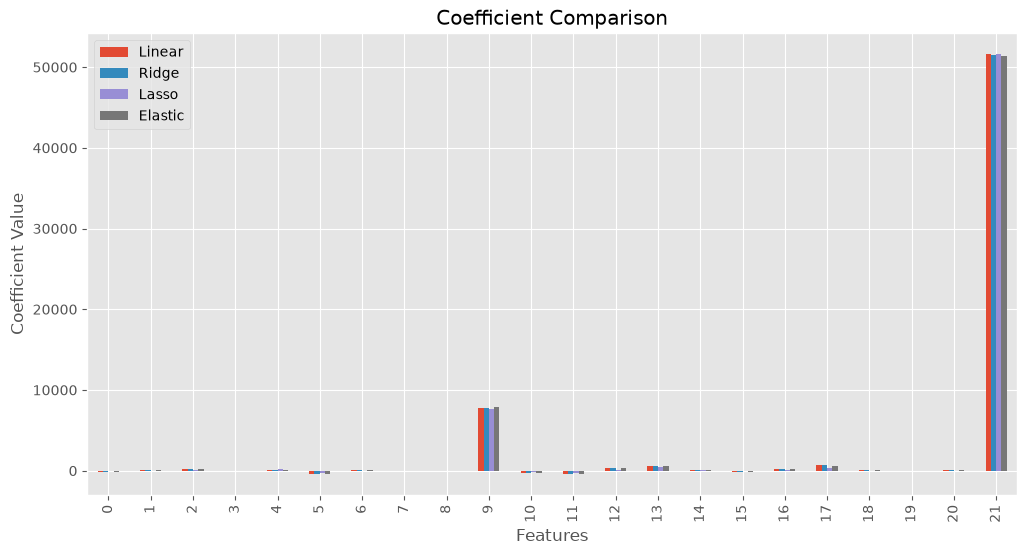

In [116]:
coef = pd.DataFrame({
    "Linear": model.coef_,
    "Ridge": grid_ridge.best_estimator_.coef_,
    "Lasso": grid_lasso.best_estimator_.coef_,
    "Elastic": grid_elastic.best_estimator_.coef_
})

coef.plot(kind="bar", figsize=(12,6))

plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Coefficient Comparison")

plt.legend()

plt.show()

## Question 18: Summary of Tuning

In [117]:
summary = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Elastic Net"],
    "Search Method": ["GridSearchCV", "GridSearchCV", "GridSearchCV"],
    "Best Parameters": [
        grid_ridge.best_params_,
        grid_lasso.best_params_,
        grid_elastic.best_params_
    ],
    "Best CV R2": [
        grid_ridge.best_score_,
        grid_lasso.best_score_,
        grid_elastic.best_score_
    ]
})

print(summary)

         Model Search Method                   Best Parameters  Best CV R2
0        Ridge  GridSearchCV                     {'alpha': 10}    0.930192
1        Lasso  GridSearchCV                    {'alpha': 100}    0.930243
2  Elastic Net  GridSearchCV  {'alpha': 0.01, 'l1_ratio': 0.8}    0.930190


## Question 19: Test Set performance

In [118]:
test_table = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Elastic Net"],
    "MAE": [lin_mae, rid_mae, lasso_mae, els_mae],
    "MSE": [lin_mse, rid_mse, lasso_mse, els_mse],
    "RMSE": [lin_rmse, rid_rmse, lasso_rmse, els_rmse],
    "R2 Score": [lin_r2, rid_r2, lasso_r2, els_r2],
    "Training Time": [
        lin_training_time,
        rid_training_time,
        lasso_training_time,
        els_training_time
    ]
})

print(test_table)

         Model           MAE           MSE          RMSE  R2 Score  \
0       Linear  10891.307659  2.329622e+08  22727.758697  0.935589   
1        Ridge  10891.340859  2.329632e+08  22727.758697  0.935589   
2        Lasso  10891.178246  2.329571e+08  22727.758697  0.935591   
3  Elastic Net  17137.946256  5.165510e+08  22727.758697  0.857181   

   Training Time  
0       0.017796  
1       0.016832  
2       1.810724  
3       0.115955  


In [ ]:
## Question 20: 